# TreasuryCaster: Modelo Preditivo para Taxas de Leilões do Tesouro Nacional

### Estimativa das taxas de leilões do Tesouro Nacional

**Problema preditivo:** Estimar as taxas do título NTN-B do Tesouro Nacional com base em dados históricos e variáveis macroeconômicas. (Variável alvo: TAXA.)

**Por que isso importa:** Títulos do Tesouro Nacional são considerados ativos "livre de risco" no contexto nacional e servem como alicerce em cálculos de custo de oportunidade, bem como de viabilidade para outros investimentos. A capacidade de prever essas taxas pode ajudar na tomada de decisões estratégicas e na gestão de riscos.

**Dataset:** [leiloes_tesouro_nacional.csv](https://www.kaggle.com/datasets/kayoricardo/leiles-da-dvida-pblica-federal-brasil/data) com dados de 2015 a 2023. Combinado com as variáveis macroeconômicas Selic e câmbio do dólar, obtidas via API do Banco Central do Brasil.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

root = Path.cwd()
while not (root / "src").is_dir() and root != root.parent:
    root = root.parent

os.chdir(root)
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

## Fase 1 - Análise Exploratória de Dados (EDA)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

from src.dataset import load_raw_data, get_selic_sgs, get_usd_sgs
from src.plots import plot_histogram, plot_histogram_by_category, plot_scatter

In [3]:
# Carrega o dataset principal de leilões do Tesouro Nacional usando a função `load_raw_data` do módulo `dataset.py`.

df = load_raw_data()

df.head()

,NUMERO_PORTARIA,VENCIMENTO,FINANCEIRO BCB,QUANTIDADE ACEITA,TAXA,TIPO,DATA,FINANCEIRO ACEITO,BENCHMARK,OFERTA,TITULO,QUANTIDADE BCB,LIQUIDACAO,FINANCEIRO ACEITO SEGUNDA VOLTA,QUANTIDADE ACEITA SEGUNDA VOLTA,TIPO_LEILAO,ACEITO/OFERTADO
0,1622,01/10/2024,0.0,1000000,10.2410,Venda,2023-12-21,9.273300e+08,LTN 12 meses,1000000,LTN,0,22/12/2023,0.000000e+00,0.0,Pré,1.000
1,1622,01/10/2025,0.0,12000000,9.7248,Venda,2023-12-21,1.017911e+10,LTN 24 meses,12000000,LTN,0,22/12/2023,0.000000e+00,0.0,Pré,1.000
2,1622,01/07/2027,0.0,7550000,9.9239,Venda,2023-12-21,5.417575e+09,LTN 48 meses,10000000,LTN,0,22/12/2023,0.000000e+00,0.0,Pré,0.755
3,1623,01/01/2029,0.0,1000000,10.1110,Venda,2023-12-21,1.043813e+09,NTN-F 6 anos,1000000,NTN-F,0,22/12/2023,0.000000e+00,0.0,Pré,1.000
4,1623,01/01/2033,0.0,350000,10.4296,Venda,2023-12-21,3.586164e+08,NTN-F 10 anos,500000,NTN-F,0,22/12/2023,1.219738e+08,118996.0,Pré,0.700


In [4]:
# Busca as séries históricas da Selic e do dólar na API do Banco Central, usando as funções `get_selic_sgs` e `get_usd_sgs` do módulo `dataset.py`.

df_selic = get_selic_sgs()
df_usd = get_usd_sgs()

In [5]:
# Verifica os últimos registros das séries históricas da Selic e do Dólar para garantir que os dados foram carregados corretamente

df_selic.tail(), df_usd.tail()

(           DATA     SELIC
 2250 2023-12-22  0.043739
 2251 2023-12-26  0.043739
 2252 2023-12-27  0.043739
 2253 2023-12-28  0.043739
 2254 2023-12-29  0.043739,
            DATA  USD_VALOR
 2250 2023-12-22     4.8619
 2251 2023-12-26     4.8368
 2252 2023-12-27     4.8306
 2253 2023-12-28     4.8413
 2254 2023-12-29     4.8413)

In [6]:
# Combina os Dataframes de Selic e Dólar com o Dataframe principal (para isso foi preciso transformar a coluna 'DATA' no objeto datetime)

df['DATA'] = pd.to_datetime(df['DATA'], format='%Y-%m-%d')  
df = df.merge(df_selic, on='DATA', how='left')
df = df.merge(df_usd, on='DATA', how='left')

In [7]:
# Inspeção do dataset enriquecido

print("INSPEÇÃO DO DATASET")
print(f"Shape: {df.shape}")
print(f"\nTipos de dados:\n{df.dtypes}")
print(f"\nValores nulos por coluna:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.describe()

INSPEÇÃO DO DATASET
Shape: (4305, 19)

Tipos de dados:
NUMERO_PORTARIA                             int64
VENCIMENTO                                    str
FINANCEIRO BCB                            float64
QUANTIDADE ACEITA                           int64
TAXA                                      float64
TIPO                                          str
DATA                               datetime64[us]
FINANCEIRO ACEITO                         float64
BENCHMARK                                     str
OFERTA                                      int64
TITULO                                        str
QUANTIDADE BCB                              int64
LIQUIDACAO                                    str
FINANCEIRO ACEITO SEGUNDA VOLTA           float64
QUANTIDADE ACEITA SEGUNDA VOLTA           float64
TIPO_LEILAO                                   str
ACEITO/OFERTADO                           float64
SELIC                                     float64
USD_VALOR                                 flo

,NUMERO_PORTARIA,FINANCEIRO BCB,QUANTIDADE ACEITA,TAXA,DATA,FINANCEIRO ACEITO,OFERTA,QUANTIDADE BCB,FINANCEIRO ACEITO SEGUNDA VOLTA,QUANTIDADE ACEITA SEGUNDA VOLTA,ACEITO/OFERTADO,SELIC,USD_VALOR
count,4305.000000,4.305000e+03,4.305000e+03,4305.000000,4305,4.305000e+03,4.305000e+03,4.305000e+03,3.247000e+03,3.247000e+03,4305.000000,4305.000000,4305.000000
mean,690.022532,5.622247e+08,1.209318e+06,6.337608,2019-09-04 23:39:15.679442,1.863560e+09,1.489389e+06,4.302049e+05,2.189125e+08,1.729719e+05,0.666551,0.033051,4.362750
min,1.000000,0.000000e+00,0.000000e+00,-0.008000,2015-01-08 00:00:00,0.000000e+00,1.000000e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.007469,2.575400
25%,291.000000,0.000000e+00,5.500000e+04,2.672400,2017-08-24 00:00:00,1.425477e+08,3.000000e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.235000,0.019930,3.686900
50%,550.000000,0.000000e+00,4.448000e+05,6.030000,2019-12-05 00:00:00,8.984802e+08,1.000000e+06,0.000000e+00,5.880188e+07,2.258600e+04,1.000000,0.029256,4.181200
75%,882.000000,0.000000e+00,1.500000e+06,10.275000,2021-09-30 00:00:00,2.166391e+09,1.500000e+06,0.000000e+00,2.698758e+08,1.674640e+05,1.000000,0.050788,5.164700
max,10646.000000,3.001775e+10,3.000000e+07,16.900000,2023-12-21 00:00:00,6.494205e+10,3.000000e+07,3.000000e+07,6.070685e+09,5.999996e+06,1.000000,0.052531,5.937200
std,842.648616,2.571391e+09,2.198548e+06,4.625877,NaN,3.176193e+09,2.173042e+06,2.291078e+06,4.273857e+08,4.043284e+05,0.406570,0.015832,0.869682


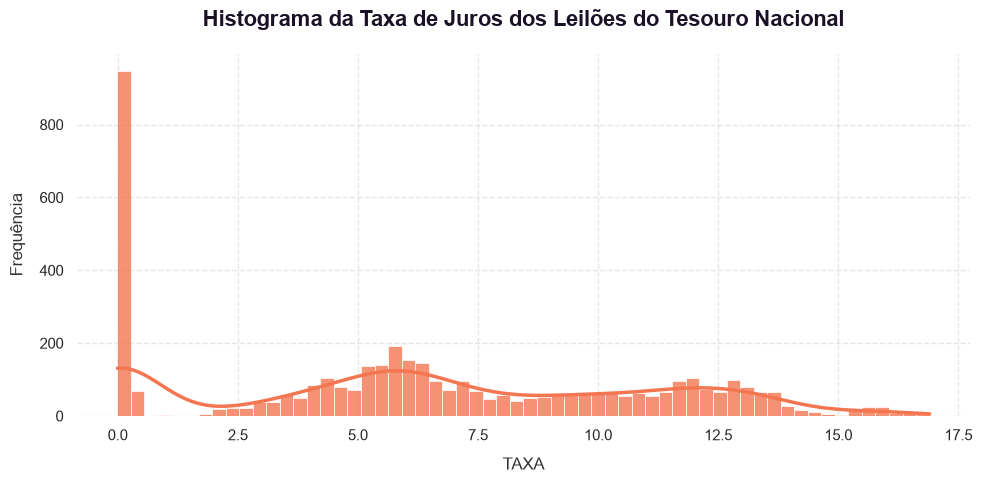

In [8]:
# Histograma da variável de interesse TAXA

plot_histogram(df, column='TAXA', title='Histograma da Taxa de Juros dos Leilões do Tesouro Nacional', filename='histogram_taxa.png')

O histograma da variável de interesse TAXA reflete uma informação importante sobre o Dataset: a presença de títulos com naturezas bem distintas. As NTN-B, por exemplo, são títulos indexados à inflação, que rendem à pessoa investidora uma taxa nominal acrescida do IPCA, enquanto as NTN-F são títulos totalmente prefixados.

Analisando o gráfico vemos um pico bem à esquerda representando possivelmente: valores zerados na tabela, mas também as taxas associadas aos títulos LFT (Tesouro Selic), que recebem uma taxa modificadora bem pequena em relação à Selic.

O pico no meio, entre 5 e 7 provavelmente indica as taxas da NTN-B, representando o rendimento do título acima da inflação.

Já o pico mais à direita, próximo ao 12,5, representaria as LTN e NTN-F, os títulos prefixados, que rendem apenas a taxa nominal e portanto têm taxas mais altas.

Este é o motivo pelo qual no escopo deste projeto faremos o recorte de análise apenas para as NTN-B.

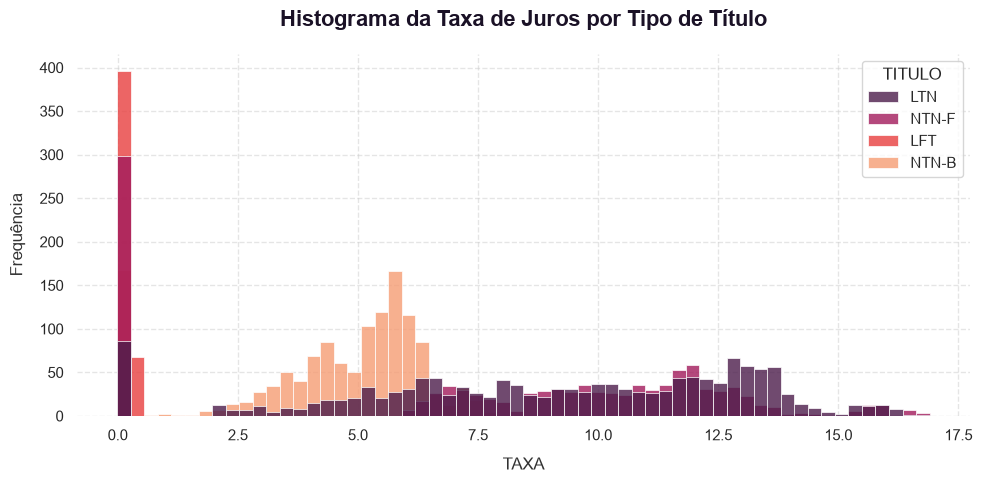

In [11]:
# Histograma da variável de interesse TAXA, segmentado por tipo de título

plot_histogram_by_category(df, column='TAXA', hue='TITULO', title='Histograma da Taxa de Juros por Tipo de Título', filename='histogram_taxa_by_tipo_titulo.png')

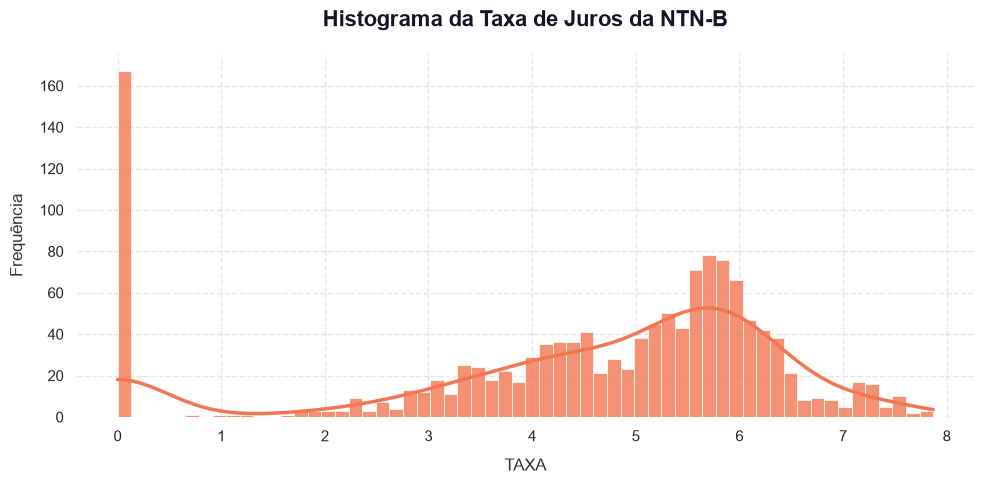

In [ ]:
# Histograma da variável de interesse TAXA apenas para os títulos do tipo NTN-B

df_ntnb = df[df['TITULO'] == 'NTN-B']
plot_histogram(df_ntnb, column='TAXA', title='Histograma da Taxa de Juros da NTN-B', filename='histogram_taxa_ntnb.png')

In [15]:
# Contagem de valores zerados na coluna TAXA do DataFrame filtrado para títulos NTN-B
(df_ntnb['TAXA'] == 0).sum()

np.int64(167)

O gráfico segmentado por título corrobora a análise anterior, mostrando que as taxas da NTN-B estão mais concentradas entre 5 e 7, enquanto as taxas das LTN e NTN-F estão concentradas acima de 10.

O histograma dos títulos NTN-B mostra que a distribuição das taxas é mais próxima da normal, ainda que com uma cauda à esquerda. O dataset contem 167 registros com taxa igual a zero para as NTN-B, que serão tratados na fase de pré-processamento.

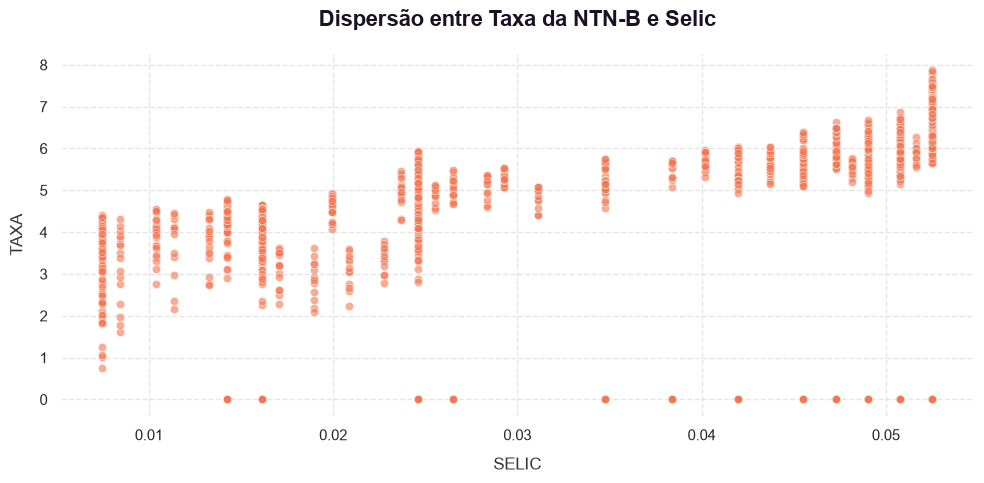

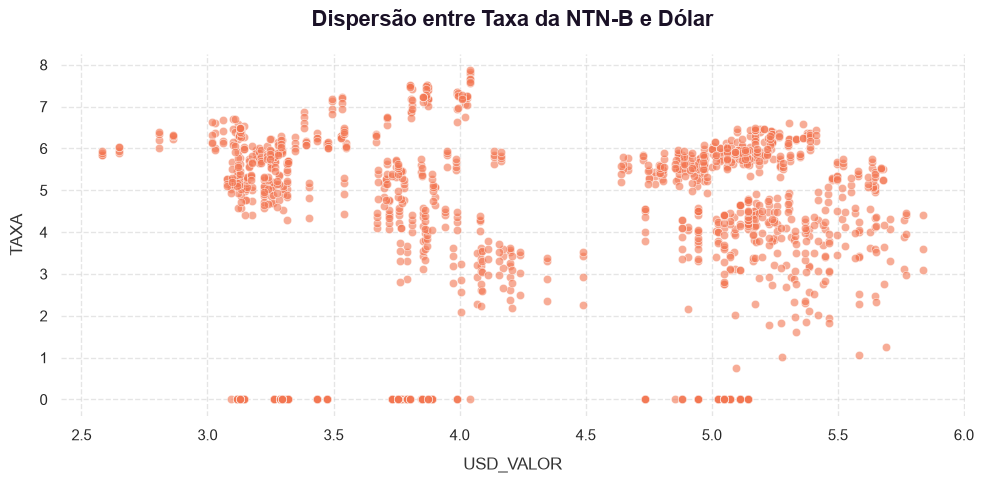

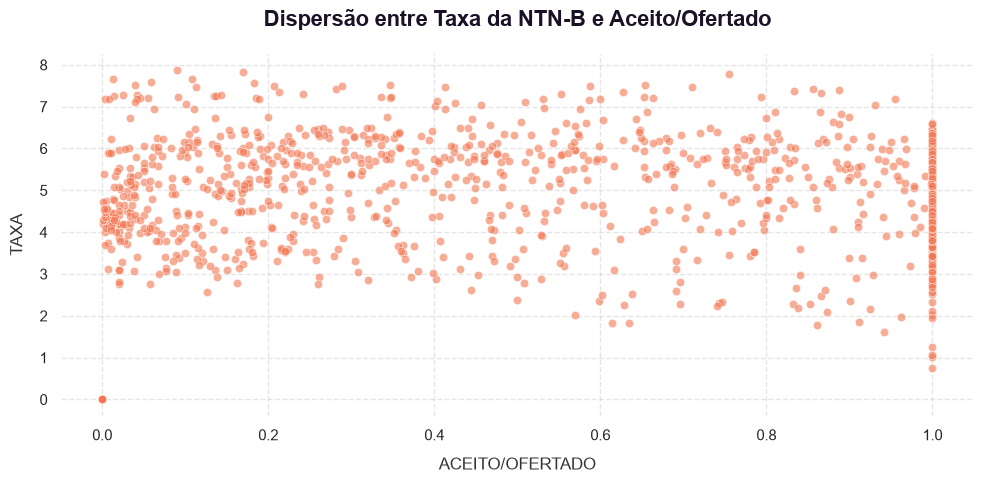

In [22]:
# Gráfico de dispersão entre TAXA e Selic, entre TAXA e Dólar, e entre TAXA e Aceito/Ofertado

plot_scatter(df_ntnb, x='SELIC', y='TAXA', title='Dispersão entre Taxa da NTN-B e Selic', filename='scatter_taxa_selic.png')
plot_scatter(df_ntnb, x='USD_VALOR', y='TAXA', title='Dispersão entre Taxa da NTN-B e Dólar', filename='scatter_taxa_usd.png')
plot_scatter(df_ntnb, x='ACEITO/OFERTADO', y='TAXA', title='Dispersão entre Taxa da NTN-B e Aceito/Ofertado', filename='scatter_taxa_aceito_ofertado.png')

Notem que a taxa Selic, embora seja uma variável numérica, não se trata de uma variável contínua, mas sim discreta, pois seus valores são definidos pelo Comitê de Política Monetária (Copom) em suas reuniões a cada 45 dias e costumam variar em saltos de 0,25% ou 0,50%.

A coluna Aceito/Ofertado representa a relação entre a quantidade de títulos oferecidos em leilão pelo Tesouro Nacional e a quantidade aceita pelo mercado. Trago aqui esta variável como uma medida de apetite do mercado, que pode influenciar a taxa de juros do título. O valor 1.0 indica que 100% dos títulos ofertados foram aceitos, enquanto valores menores que 1.0 indicam que o mercado aceitou menos títulos do que o ofertado.

In [ ]:
# Mapa de calor de correlação de Pearson